# NB09b: Unsupervised Baselines + UISEM Ensemble (v20)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


## Unsupervised baselines (no training, threshold-only):
- B0: Single-feature change baselines (all baseline/assessment pairs)
- B1: PWTT (Pixel-Wise T-Test, Ballinger 2024, AUC=0.87 on Ukraine)
- B2: CCD (Coherence Change Detection, Scher & Van Den Hoek 2025)
- B3: Log-ratio (Aimaiti et al. 2022)
- B4: Progressive modality ladder (CARD -> +COH -> +optical -> +methods)

## Supervised ensemble (Ahmad et al. 2024 UISEM adaptation):
- B5: UISEM baseline (RF+GB+XGB soft voting, GroupKFold)
- B6: AdaBoost ablation
- B7: UISEM sensor ablation
- B8: Comparison table (all methods + NB09a reference)

## Parquets:
- `bda_product_prepost` -- B0, B2 (approx), B3, B4, B5-B8
- `bda_scene_card` -- B1 PWTT (exact, per-date t-test)
- `bda_temporal_coh` -- B2 CCD (exact, per-date coherence)

## References:
- Ballinger 2024: arXiv:2405.06323 (PWTT, AUC=0.87)
- Scher & Van Den Hoek 2023: AGU Fall Meeting (CCD nationwide)
- Aimaiti et al. 2022: Remote Sensing 14(24), 6239 (S1+S2, Kyiv)
- Ahmad et al. 2024: Int. J. Appl. Earth Obs. Geoinf. 132, 104013 (UISEM)

# CONFIG + GLOBAL SETUP


In [1]:
# @title CELL 3: NB09b CONFIG + GLOBAL SETUP
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-06-28 00:33:49
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     937.8/7452.0 GB (6514.3 GB free)
  GDrive (F:)     1405.8/3726.0 GB (2320.2 GB free)
  Local data      11566.2/14901.9 GB (3335.6 GB free)
  Data stack      1405.8/3726.0 GB (2320.2 GB free)
  WSL ext4        69.0/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: PARQUET LOADER + SHARED EVALUATION


In [2]:
# @title CELL S0: NB09b PARQUET LOADER + SHARED EVALUATION
# =============================================================================
# Loads bda_product_prepost + bda_scene_card (for PWTT) + bda_scene_coh (for CCD).
# Shared evaluate_groupkfold() for UISEM cells.
# All experiments use GroupKFold by city.
# =============================================================================
import sys, importlib, re, time, gc
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, VotingClassifier, AdaBoostClassifier)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from scipy import stats as scipy_stats

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

print("=" * 70)
print("CELL S0: NB09b PARQUET LOADER")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import stack_loader
importlib.reload(stack_loader)
from stack_loader import load_dataset, get_feature_groups

# ---- product_prepost (per-tier) ----
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
df_pp = load_tier_parquets(PARQUET_PREPOST_TIER_FMT, _tiers)
df_bldg = load_tier_parquets(PARQUET_BUILDINGS_TIER_FMT, _tiers)

CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)

# merge features + building metadata
join_cols = ['building_id', 'city']
bldg_extra = [c for c in df_bldg.columns if c not in df_pp.columns]
df = df_pp.merge(df_bldg[join_cols + bldg_extra], on=join_cols, how='left')
del df_pp
df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
df = df[df['damage_binary'] >= 0].copy()
print(f"  product_prepost: {len(df)} buildings, {df['city'].nunique()} cities")

TARGET_COL = 'damage_binary'
N_FOLDS = 5
feature_groups = get_feature_groups(df)
EXCLUDE_GROUPS = {'meta', 'cloud_freq', 'obs_count', 'other'}

# feature lists (__ naming)
card_baseline = [c for c in df.columns if re.match(r's1__(vv|vh)__baseline__', c)]
card_assessment = [c for c in df.columns if re.match(r's1__(vv|vh)__assessment__', c)]
card_prepost = card_baseline + card_assessment

coh_cols = []
for gname, cols in feature_groups.items():
    if 'coh' in gname.lower() and gname not in EXCLUDE_GROUPS:
        coh_cols.extend([c for c in cols if c in df.columns])
coh_cols = list(dict.fromkeys(coh_cols))

ms_cols = []
for gname, cols in feature_groups.items():
    if gname not in EXCLUDE_GROUPS and any(gname.startswith(p) for p in ('comp_', 'lu_', 'landuse', 's2_', 'idx_', 'spectral', 'cd_', 'fire', 'vis')):
        ms_cols.extend([c for c in cols if c in df.columns])
ms_cols = list(dict.fromkeys(ms_cols))

delta_cols = [c for c in df.columns if '__delta__' in c]

all_feature_cols = []
for gname, cols in feature_groups.items():
    if gname not in EXCLUDE_GROUPS:
        all_feature_cols.extend([c for c in cols if c in df.columns])
all_feature_cols = list(dict.fromkeys(all_feature_cols))

print(f"  card_prepost: {len(card_prepost)}, coh: {len(coh_cols)}, ms: {len(ms_cols)}, delta: {len(delta_cols)}, all: {len(all_feature_cols)}")

# sensor ablation groups
ABLATION_GROUPS = {
    'card_only': card_prepost,
    'coh_only': coh_cols,
    'ms_only': ms_cols,
    'delta_only': delta_cols,
    'card+coh': list(dict.fromkeys(card_prepost + coh_cols)),
    'card+ms': list(dict.fromkeys(card_prepost + ms_cols)),
    'coh+ms': list(dict.fromkeys(coh_cols + ms_cols)),
    'card+coh+delta': list(dict.fromkeys(card_prepost + coh_cols + delta_cols)),
    'all_multimodal': all_feature_cols,
}
ABLATION_GROUPS = {k: [c for c in v if c in df.columns] for k, v in ABLATION_GROUPS.items()}

# ---- scene_card (for exact PWTT) ----
df_scene_card = None
try:
    df_scene_card = load_tier_parquets(PARQUET_SCENE_CARD_TIER_FMT, _tiers)
    df_scene_card = df_scene_card[df_scene_card['city'].isin(CITIES_TO_PROCESS)]
    print(f"  scene_card: {len(df_scene_card)} rows (for PWTT)")
except FileNotFoundError:
    print(f"  scene_card: NOT FOUND (PWTT will use product_prepost approximation)")

# ---- scene_coh time series (for exact CCD) ----
# V1 has no bda_temporal_coh; the coherence time series is bda_scene_coh
# (PARQUET_SCENE_COH_TIER_FMT), which carries period_label + coh*_mean columns
# exactly as the CCD cell (B-series) expects. Variable name kept as df_temporal_coh
# so downstream cells are unchanged.
df_temporal_coh = None
try:
    df_temporal_coh = load_tier_parquets(PARQUET_SCENE_COH_TIER_FMT, _tiers)
    df_temporal_coh = df_temporal_coh[df_temporal_coh['city'].isin(CITIES_TO_PROCESS)]
    print(f"  scene_coh (CCD): {len(df_temporal_coh)} rows, "
          f"period_label={'period_label' in df_temporal_coh.columns}")
except (FileNotFoundError, AttributeError, NameError, KeyError):
    df_temporal_coh = None
    print(f"  scene_coh: NOT FOUND (CCD will use product_prepost approximation)")

# ---- shared evaluation ----
EXPERIMENT_LOG = {}

def prepare_Xy(feat_cols, target_df=None):
    src = target_df if target_df is not None else df
    avail = [c for c in feat_cols if c in src.columns]
    if len(avail) < 2:
        return None, None, None, None
    df_valid = src[src[TARGET_COL] >= 0].copy()
    row_mask = ~df_valid[avail].isna().all(axis=1)
    df_sub = df_valid[row_mask]
    nan_col = df_sub[avail].isna().all()
    clean = [c for c in avail if not nan_col[c]]
    if len(clean) < 2:
        return None, None, None, None
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(df_sub[clean].values)
    y = df_sub[TARGET_COL].values
    groups = df_sub['city'].values
    return X, y, groups, clean

def evaluate_groupkfold(clf, X, y, groups, label="", n_folds=N_FOLDS):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {label}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_aucs = []
    for train_idx, test_idx in gkf.split(X, y, groups):
        clf_copy = clone(clf)
        clf_copy.fit(X[train_idx], y[train_idx])
        if hasattr(clf_copy, 'predict_proba'):
            y_proba_oof[test_idx] = clf_copy.predict_proba(X[test_idx])[:, 1]
        else:
            raw = clf_copy.decision_function(X[test_idx])
            y_proba_oof[test_idx] = 1.0 / (1.0 + np.exp(-raw))
        if len(np.unique(y[test_idx])) > 1:
            fold_aucs.append(roc_auc_score(y[test_idx], y_proba_oof[test_idx]))
    valid = ~np.isnan(y_proba_oof)
    auc = roc_auc_score(y[valid], y_proba_oof[valid])
    f1 = f1_score(y[valid], (y_proba_oof[valid] >= 0.5).astype(int))
    res = {'auc': auc, 'f1': f1, 'auc_std': np.std(fold_aucs), 'fold_aucs': fold_aucs,
           'y_true': y[valid], 'y_proba': y_proba_oof[valid], 'groups': groups[valid],
           'n_features': X.shape[1], 'experiment': label}
    EXPERIMENT_LOG[label] = res
    print(f"    {label:40s}: AUC={auc:.3f} (+/-{np.std(fold_aucs):.3f})  F1={f1:.3f}")
    return res

def build_uisem(include_adaboost=True):
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                       n_jobs=-1, class_weight='balanced')),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                           random_state=RANDOM_STATE)),
    ]
    if HAS_XGB:
        estimators.append(('xgb', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                  scale_pos_weight=5, eval_metric='logloss', verbosity=0)))
    if include_adaboost:
        estimators.append(('ab', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)))
    return VotingClassifier(estimators=estimators, voting='soft')

print(f"\n  Shared: prepare_Xy(), evaluate_groupkfold(), build_uisem()")
print(f"  EXPERIMENT_LOG: global registry for B8 comparison")




# ---- RESULT REGISTRY (for NB13 consolidation) ----
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09b')

def log_result(res, cell_id='', parquet_name='', feature_set_name='',
               classifier_name='', feature_cols=None, groups=None,
               cv_method='GroupKFold', note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id,
        experiment_name=res.get('experiment', res.get('label', '')),
        parquet_name=parquet_name,
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name=classifier_name,
        feature_set_name=feature_set_name,
        feature_cols=feature_cols,
        cv_method=cv_method,
        n_folds=N_FOLDS,
        imputation='median',
        y_true=res.get('y_true'),
        y_proba=res.get('y_proba'),
        groups=res.get('groups', groups),
        note=note,
        tags=tags or [],
    )

# ---- OUTPUT + SAVE HELPERS ----
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_ROOT / 'nb09b'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        import json as _j
        with open(path, 'w') as fh:
            _j.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

print(f"  Output: {OUT_DIR}")
print(f"  Helpers: save_result(), save_fig()")

CELL S0: NB09b PARQUET LOADER
  load_tier_parquets: 3 tiers, 907371 rows
  load_tier_parquets: 3 tiers, 907371 rows
  product_prepost: 598595 buildings, 21 cities
  card_prepost: 96, coh: 18, ms: 192, delta: 22, all: 311
  load_tier_parquets: 3 tiers, 20571668 rows
  scene_card: 20571668 rows (for PWTT)
  load_tier_parquets: 3 tiers, 7087374 rows
  scene_coh (CCD): 7087374 rows, period_label=True

  Shared: prepare_Xy(), evaluate_groupkfold(), build_uisem()
  EXPERIMENT_LOG: global registry for B8 comparison
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260628_003554)
  Output: /content/drive_f/masterthesis/results/nb09b
  Helpers: save_result(), save_fig()


# CELL B0: SINGLE-FEATURE CHANGE BASELINES

Unsupervised: for every baseline/assessment mean pair in bda_product_prepost,
compute simple pre-post change score and evaluate AUC. Shows what each individual
sensor/product gives "for free" with zero ML.


CELL B0: SINGLE-FEATURE CHANGE BASELINES
  Found 6 baseline/assessment mean pairs
  Label                          BL column                                     AS column
  s1_vh_mean                     s1__vh__baseline__mean_mean                   s1__vh__assessment__mean_mean
  s1_vh_std                      s1__vh__baseline__mean_std                    s1__vh__assessment__mean_std
  s1_vh_max                      s1__vh__baseline__mean_max                    s1__vh__assessment__mean_max
  s1_vv_mean                     s1__vv__baseline__mean_mean                   s1__vv__assessment__mean_mean
  s1_vv_std                      s1__vv__baseline__mean_std                    s1__vv__assessment__mean_std
  s1_vv_max                      s1__vv__baseline__mean_max                    s1__vv__assessment__mean_max

  Feature                              N  AUC(drop)  AUC(-chg) AUC(|chg|)       Best Direction 
  ------------------------------ ------- ---------- ---------- ---------- --------

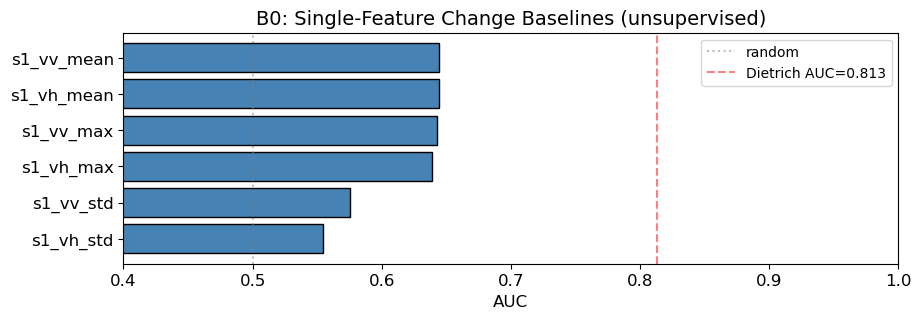

  Plot: cell_b0/single_feature_baselines_20260628_003604.png


In [3]:
# @title CELL B0: SINGLE-FEATURE CHANGE BASELINES (unsupervised)
# =============================================================================
# For every baseline/assessment column pair in bda_product_prepost, compute
# simple pre-post change score and evaluate AUC against UNOSAT labels.
# Shows what each individual sensor/product gives "for free" with zero ML.
# Covers: CARD VV/VH, COH VV/VH, NDVI, NBR, BSI, and any other pairs.
# Parquet: bda_product_prepost.
# =============================================================================
print("=" * 70)
print("CELL B0: SINGLE-FEATURE CHANGE BASELINES")
print("=" * 70)

# discover all baseline/assessment mean pairs
baseline_cols = [c for c in df.columns if '__baseline__mean' in c]
assessment_cols = [c for c in df.columns if '__assessment__mean' in c]

# match pairs by replacing period token
pairs = []
for bl in baseline_cols:
    as_candidate = bl.replace('__baseline__', '__assessment__')
    if as_candidate in df.columns:
        label = bl.replace('__baseline__mean', '').replace('__', '_')
        pairs.append((label, bl, as_candidate))

print(f"  Found {len(pairs)} baseline/assessment mean pairs")
print(f"  {'Label':<30s} {'BL column':<45s} {'AS column'}")
for label, bl, asc in pairs:
    print(f"  {label:<30s} {bl:<45s} {asc}")

# evaluate each pair
b0_results = {}

print(f"\n  {'Feature':<30s} {'N':>7s} {'AUC(drop)':>10s} {'AUC(-chg)':>10s} {'AUC(|chg|)':>10s} {'Best':>10s} {'Direction':<10s}")
print(f"  {'-'*30} {'-'*7} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

for label, bl_col, as_col in sorted(pairs, key=lambda x: x[0]):
    sub = df[['building_id', 'city', TARGET_COL, bl_col, as_col]].dropna()
    sub = sub[sub[TARGET_COL] >= 0]
    if len(sub) < 50 or sub[TARGET_COL].nunique() < 2:
        print(f"  {label:<30s} {'SKIP':>7s}")
        continue

    y = sub[TARGET_COL].values
    change = sub[as_col].values - sub[bl_col].values
    drop = sub[bl_col].values - sub[as_col].values

    auc_drop = roc_auc_score(y, drop)
    auc_neg = roc_auc_score(y, -change)
    auc_abs = roc_auc_score(y, np.abs(change))

    auc_best = max(auc_drop, auc_neg, auc_abs)
    if auc_best == auc_drop:
        direction = 'drop'
        best_scores = drop
    elif auc_best == auc_neg:
        direction = '-change'
        best_scores = -change
    else:
        direction = '|change|'
        best_scores = np.abs(change)

    print(f"  {label:<30s} {len(sub):>7d} {auc_drop:>10.3f} {auc_neg:>10.3f} {auc_abs:>10.3f} {auc_best:>10.3f} {direction:<10s}")

    exp_name = f'B0_single_{label}'
    EXPERIMENT_LOG[exp_name] = {
        'auc': auc_best, 'f1': np.nan, 'n_features': 1,
        'method': 'unsupervised', 'direction': direction,
    }
    b0_results[label] = {
        'auc': auc_best, 'direction': direction,
        'n': len(sub), 'bl_col': bl_col, 'as_col': as_col,
        'scores': best_scores, 'building_ids': sub['building_id'].values,
        'cities': sub['city'].values, 'y': y,
    }

    registry.log_experiment(
        cell_id='cell_b0', experiment_name=exp_name,
        parquet_name='bda_product_prepost',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='unsupervised_change',
        feature_set_name=label, feature_cols=[bl_col, as_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores,
        groups=sub['city'].values,
        note=f'Single-feature pre/post change: {label}, direction={direction}',
        tags=['unsupervised', 'single_feature', label],
    )

# rank
if b0_results:
    print(f"\n  Ranking (best to worst):")
    for rank, (label, r) in enumerate(sorted(b0_results.items(), key=lambda x: -x[1]['auc']), 1):
        print(f"    {rank:2d}. {label:<30s} AUC={r['auc']:.3f}  ({r['direction']}, n={r['n']})")

# bar chart
if b0_results:
    import matplotlib.pyplot as plt
    labels_sorted = sorted(b0_results.keys(), key=lambda k: b0_results[k]['auc'])
    aucs = [b0_results[k]['auc'] for k in labels_sorted]
    colors = []
    for k in labels_sorted:
        if k.startswith('s1_coh'):
            colors.append('orange')
        elif k.startswith('s1_'):
            colors.append('steelblue')
        else:
            colors.append('green')
    fig, ax = plt.subplots(figsize=(10, max(3, len(labels_sorted) * 0.35)))
    ax.barh(labels_sorted, aucs, color=colors, edgecolor='black')
    ax.set_xlabel('AUC')
    ax.set_xlim(0.4, 1.0)
    ax.set_title('B0: Single-Feature Change Baselines (unsupervised)')
    ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='random')
    ax.axvline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich AUC=0.813')
    ax.legend()
    save_fig(fig, 'single_feature_baselines', 'cell_b0')


# CELL B1: PIXEL-WISE T-TEST (Ballinger 2024)

Unsupervised: Welch t-test on pre vs post CARD VV/VH per building. No training.


In [4]:
# @title CELL B1: PWTT (Ballinger 2024, unsupervised)
# =============================================================================
# Welch t-test on pre vs post backscatter per building.
# If bda_scene_card exists: exact per-date t-test (vectorized).
# Else: approximate from product_prepost mean/std/count.
# Tests BOTH VV and VH (Ballinger used both polarizations).
# Output: t-statistic per building = damage score. AUC from UNOSAT labels.
# Parquet: bda_scene_card (preferred) or bda_product_prepost (fallback).
# =============================================================================
print("=" * 70)
print("CELL B1: PWTT (Pixel-Wise T-Test, Ballinger 2024)")
print("=" * 70)

from scipy.stats import t as t_dist

def vectorized_welch_ttest(scene_df, val_col, pol_label):
    """Vectorized Welch t-test across all buildings. Returns DataFrame or None."""
    tmp = scene_df[['city', 'building_id', 'period_label', val_col]].copy()
    tmp = tmp.dropna(subset=[val_col])
    tmp['period_group'] = 'drop'
    tmp.loc[tmp['period_label'] == 'prebattle', 'period_group'] = 'pre'
    tmp.loc[tmp['period_label'].isin(['crossbattle', 'postbattle']), 'period_group'] = 'post'
    tmp = tmp[tmp['period_group'] != 'drop']

    agg = tmp.groupby(['city', 'building_id', 'period_group'])[val_col].agg(
        ['mean', 'std', 'count']
    ).reset_index()
    agg.columns = ['city', 'building_id', 'period_group', 'mean', 'std', 'count']

    pre = agg[agg['period_group'] == 'pre'].set_index(['city', 'building_id'])
    post = agg[agg['period_group'] == 'post'].set_index(['city', 'building_id'])

    joined = pre.join(post, lsuffix='_pre', rsuffix='_post', how='inner')
    joined = joined[(joined['count_pre'] >= 2) & (joined['count_post'] >= 2)]

    if len(joined) == 0:
        print(f"    {pol_label}: no buildings with >= 2 pre AND >= 2 post observations")
        return None

    var_pre = joined['std_pre'] ** 2
    var_post = joined['std_post'] ** 2
    n_pre = joined['count_pre']
    n_post = joined['count_post']
    denom = np.sqrt(var_pre / n_pre + var_post / n_post + 1e-30)
    joined[f'pwtt_t_{pol_label}'] = (joined['mean_post'] - joined['mean_pre']) / denom

    num_df = (var_pre / n_pre + var_post / n_post) ** 2
    den_df = ((var_pre / n_pre) ** 2 / (n_pre - 1) +
              (var_post / n_post) ** 2 / (n_post - 1))
    welch_df = num_df / (den_df + 1e-30)
    joined[f'pwtt_p_{pol_label}'] = 2 * t_dist.sf(np.abs(joined[f'pwtt_t_{pol_label}']), welch_df)

    result = joined[[f'pwtt_t_{pol_label}', f'pwtt_p_{pol_label}']].reset_index()
    print(f"    {pol_label}: {len(result)} buildings")
    return result

pwtt_scores = None
pwtt_scores_vh = None

if df_scene_card is not None and 'period_label' in df_scene_card.columns:
    print("  Mode: EXACT (per-date values from bda_scene_card)")

    # VV
    vv_col = [c for c in df_scene_card.columns if 'vv' in c.lower() and 'mean' in c.lower()]
    if not vv_col:
        vv_col = [c for c in df_scene_card.columns if 'vv' in c.lower() and c not in ('city', 'building_id', 'date', 'timestep', 'period_label')]
    if vv_col:
        print(f"  VV column: {vv_col[0]}")
        pwtt_vv = vectorized_welch_ttest(df_scene_card, vv_col[0], 'vv')
        if pwtt_vv is not None:
            pwtt_vv = pwtt_vv.merge(df[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                                     on=['building_id', 'city'], how='inner')
            pwtt_vv['pwtt_t'] = pwtt_vv['pwtt_t_vv']
            pwtt_vv['pwtt_p'] = pwtt_vv['pwtt_p_vv']
            pwtt_scores = pwtt_vv
    else:
        print("  No VV column found in scene_card")

    # VH
    vh_col = [c for c in df_scene_card.columns if 'vh' in c.lower() and 'mean' in c.lower()]
    if not vh_col:
        vh_col = [c for c in df_scene_card.columns if 'vh' in c.lower() and c not in ('city', 'building_id', 'date', 'timestep', 'period_label')]
    if vh_col:
        print(f"  VH column: {vh_col[0]}")
        pwtt_vh = vectorized_welch_ttest(df_scene_card, vh_col[0], 'vh')
        if pwtt_vh is not None:
            pwtt_vh = pwtt_vh.merge(df[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                                     on=['building_id', 'city'], how='inner')
            pwtt_scores_vh = pwtt_vh
    else:
        print("  No VH column found in scene_card")

if pwtt_scores is None:
    print("  Mode: APPROXIMATE (from product_prepost baseline/assessment mean/std)")
    bl_mean = [c for c in df.columns if c.startswith('s1__vv__baseline__mean')]
    as_mean = [c for c in df.columns if c.startswith('s1__vv__assessment__mean')]
    bl_std = [c for c in df.columns if c.startswith('s1__vv__baseline__std')]
    as_std = [c for c in df.columns if c.startswith('s1__vv__assessment__std')]

    if bl_mean and as_mean and bl_std and as_std:
        sub = df[['building_id', 'city', TARGET_COL] + bl_mean + as_mean + bl_std + as_std].dropna()
        t_approx = (sub[as_mean[0]] - sub[bl_mean[0]]) / np.sqrt(sub[bl_std[0]]**2 + sub[as_std[0]]**2 + 1e-10)
        sub = sub.copy()
        sub['pwtt_t'] = t_approx
        pwtt_scores = sub[['building_id', 'city', TARGET_COL, 'pwtt_t']].copy()
        print(f"  Computed approximate t for {len(pwtt_scores)} buildings (VV)")
    else:
        print(f"  Cannot compute PWTT: missing baseline/assessment mean/std columns")

    bl_mean_vh = [c for c in df.columns if c.startswith('s1__vh__baseline__mean')]
    as_mean_vh = [c for c in df.columns if c.startswith('s1__vh__assessment__mean')]
    bl_std_vh = [c for c in df.columns if c.startswith('s1__vh__baseline__std')]
    as_std_vh = [c for c in df.columns if c.startswith('s1__vh__assessment__std')]
    if bl_mean_vh and as_mean_vh and bl_std_vh and as_std_vh:
        sub_vh = df[['building_id', 'city', TARGET_COL] + bl_mean_vh + as_mean_vh + bl_std_vh + as_std_vh].dropna()
        t_approx_vh = (sub_vh[as_mean_vh[0]] - sub_vh[bl_mean_vh[0]]) / np.sqrt(sub_vh[bl_std_vh[0]]**2 + sub_vh[as_std_vh[0]]**2 + 1e-10)
        sub_vh = sub_vh.copy()
        sub_vh['pwtt_t_vh'] = t_approx_vh
        pwtt_scores_vh = sub_vh[['building_id', 'city', TARGET_COL, 'pwtt_t_vh']].copy()
        print(f"  Computed approximate t for {len(pwtt_scores_vh)} buildings (VH)")

# ---- evaluate ----
def evaluate_pwtt(scores_df, t_col, exp_name, pol_label):
    if scores_df is None or len(scores_df) < 50:
        print(f"  {exp_name}: insufficient data")
        return None
    y = scores_df[TARGET_COL].values
    if len(np.unique(y)) < 2:
        print(f"  {exp_name}: only one class in {len(y)} samples, cannot compute AUC")
        return None
    scores_abs = np.abs(scores_df[t_col].values)
    scores_neg = -scores_df[t_col].values
    auc_abs = roc_auc_score(y, scores_abs)
    auc_neg = roc_auc_score(y, scores_neg)
    auc_best = max(auc_abs, auc_neg)
    direction = "|t|" if auc_abs >= auc_neg else "-t"
    best_scores = scores_abs if auc_abs >= auc_neg else scores_neg
    print(f"\n  {exp_name} results ({pol_label}):")
    print(f"    AUC (|t|):  {auc_abs:.3f}")
    print(f"    AUC (-t):   {auc_neg:.3f}")
    print(f"    Best:       {auc_best:.3f} (using {direction})")
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1, 'method': 'unsupervised', 'direction': direction}
    registry.log_experiment(
        cell_id='cell_b1', experiment_name=exp_name,
        parquet_name='bda_scene_card' if df_scene_card is not None else 'bda_product_prepost',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='unsupervised_ttest',
        feature_set_name=f'pwtt_{pol_label}', feature_cols=[t_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores,
        groups=scores_df['city'].values,
        note=f'Ballinger 2024 PWTT {pol_label}, direction={direction}, paper AUC=0.87',
        tags=['unsupervised', 'pwtt', 'ballinger', pol_label],
    )
    return auc_best

auc_vv = evaluate_pwtt(pwtt_scores, 'pwtt_t', 'B1_PWTT_VV', 'VV')
auc_vh = evaluate_pwtt(pwtt_scores_vh, 'pwtt_t_vh', 'B1_PWTT_VH', 'VH')

# combined VV+VH
if pwtt_scores is not None and pwtt_scores_vh is not None:
    merged_pwtt = pwtt_scores[['building_id', 'city', TARGET_COL, 'pwtt_t']].merge(
        pwtt_scores_vh[['building_id', 'city', 'pwtt_t_vh']], on=['building_id', 'city'], how='inner')
    if len(merged_pwtt) > 50:
        combined_t = np.abs(merged_pwtt['pwtt_t'].values) + np.abs(merged_pwtt['pwtt_t_vh'].values)
        y_comb = merged_pwtt[TARGET_COL].values
        if len(np.unique(y_comb)) >= 2:
            auc_comb = roc_auc_score(y_comb, combined_t)
            print(f"\n  PWTT VV+VH combined: AUC={auc_comb:.3f} ({len(merged_pwtt)} buildings)")
            EXPERIMENT_LOG['B1_PWTT_VV+VH'] = {'auc': auc_comb, 'f1': np.nan, 'n_features': 2, 'method': 'unsupervised'}
            registry.log_experiment(
                cell_id='cell_b1', experiment_name='B1_PWTT_VV+VH',
                parquet_name='bda_scene_card' if df_scene_card is not None else 'bda_product_prepost',
                tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
                classifier_name='unsupervised_ttest',
                feature_set_name='pwtt_vv+vh', feature_cols=['pwtt_t', 'pwtt_t_vh'],
                cv_method='unsupervised', n_folds=0, imputation='none',
                y_true=y_comb, y_proba=combined_t,
                groups=merged_pwtt['city'].values,
                note='Ballinger 2024 PWTT VV+VH combined, paper AUC=0.87',
                tags=['unsupervised', 'pwtt', 'ballinger', 'combined'],
            )

print(f"\n  Ballinger reference: AUC=0.87 (calibrated on Ukraine)")


CELL B1: PWTT (Pixel-Wise T-Test, Ballinger 2024)
  Mode: EXACT (per-date values from bda_scene_card)
  VV column: s1__vv_mean
    vv: 543543 buildings
  VH column: s1__vh_mean
    vh: 543543 buildings

  B1_PWTT_VV results (VV):
    AUC (|t|):  0.500
    AUC (-t):   0.618
    Best:       0.618 (using -t)
  REG: B1_PWTT_VV                                    AUC=0.6177 F1=0.0572 n=368288 feat=1 cities=21 [NB09b/cell_b1]

  B1_PWTT_VH results (VH):
    AUC (|t|):  0.489
    AUC (-t):   0.625
    Best:       0.625 (using -t)
  REG: B1_PWTT_VH                                    AUC=0.6246 F1=0.0587 n=368288 feat=1 cities=21 [NB09b/cell_b1]

  PWTT VV+VH combined: AUC=0.502 (368288 buildings)
  REG: B1_PWTT_VV+VH                                 AUC=0.5017 F1=0.0345 n=368288 feat=2 cities=21 [NB09b/cell_b1]

  Ballinger reference: AUC=0.87 (calibrated on Ukraine)


# CELL B2: COHERENCE CHANGE DETECTION (Scher & Van Den Hoek 2025)


In [5]:
# @title CELL B2: CCD (Coherence Change Detection, unsupervised)
# =============================================================================
# Pre-battle COH mean vs post-battle COH. COH drop = damage.
# If bda_temporal_coh exists: exact per-date CCD (vectorized).
# Else: approximate from product_prepost COH baseline/assessment features.
# Parquet: bda_temporal_coh (preferred) or bda_product_prepost (fallback).
# =============================================================================
print("=" * 70)
print("CELL B2: CCD (Coherence Change Detection)")
print("=" * 70)

ccd_scores_exact = None

# ---- EXACT: per-date CCD from temporal_coh ----
if df_temporal_coh is not None and 'period_label' in df_temporal_coh.columns:
    print("  Mode: EXACT (per-date values from bda_temporal_coh)")
    coh_val_cols = [c for c in df_temporal_coh.columns if 'coh' in c.lower() and 'mean' in c.lower()]
    if not coh_val_cols:
        coh_val_cols = [c for c in df_temporal_coh.columns if 'coh' in c.lower()
                        and c not in ('city', 'building_id', 'date', 'timestep', 'period_label')]
    if coh_val_cols:
        for coh_col in coh_val_cols[:2]:
            pol = 'vv' if 'vv' in coh_col.lower() else 'vh' if 'vh' in coh_col.lower() else 'coh'
            print(f"  Processing {coh_col} ({pol})")

            tmp = df_temporal_coh[['city', 'building_id', 'period_label', coh_col]].copy()
            tmp = tmp.dropna(subset=[coh_col])
            tmp['period_group'] = 'drop'
            tmp.loc[tmp['period_label'] == 'prebattle', 'period_group'] = 'pre'
            tmp.loc[tmp['period_label'].isin(['crossbattle', 'postbattle']), 'period_group'] = 'post'
            tmp = tmp[tmp['period_group'] != 'drop']

            agg = tmp.groupby(['city', 'building_id', 'period_group'])[coh_col].mean().unstack('period_group')
            if 'pre' in agg.columns and 'post' in agg.columns:
                agg = agg.dropna(subset=['pre', 'post'])
                agg['ccd_score'] = agg['pre'] - agg['post']
                ccd_df = agg[['ccd_score']].reset_index()
                ccd_df = ccd_df.merge(df[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                                       on=['building_id', 'city'], how='inner')

                if len(ccd_df) > 50 and ccd_df[TARGET_COL].nunique() >= 2:
                    y = ccd_df[TARGET_COL].values
                    auc_drop = roc_auc_score(y, ccd_df['ccd_score'].values)
                    exp_name = f'B2_CCD_exact_{pol}'
                    print(f"    {pol}: AUC(drop)={auc_drop:.3f}  ({len(ccd_df)} buildings)")
                    EXPERIMENT_LOG[exp_name] = {'auc': auc_drop, 'f1': np.nan, 'n_features': 1, 'method': 'unsupervised'}
                    registry.log_experiment(
                        cell_id='cell_b2', experiment_name=exp_name,
                        parquet_name='bda_temporal_coh',
                        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
                        classifier_name='unsupervised_ccd',
                        feature_set_name=f'coh_change_{pol}', feature_cols=[coh_col],
                        cv_method='unsupervised', n_folds=0, imputation='none',
                        y_true=y, y_proba=ccd_df['ccd_score'].values,
                        groups=ccd_df['city'].values,
                        note=f'Scher & Van Den Hoek 2025 CCD exact per-date {pol}',
                        tags=['unsupervised', 'ccd', 'coherence', 'exact', pol],
                    )
                    if ccd_scores_exact is None:
                        ccd_scores_exact = ccd_df
    else:
        print("  No COH value column found in temporal_coh")

# ---- APPROXIMATE: from product_prepost ----
coh_bl_mean = [c for c in df.columns if 'coh' in c.lower() and 'baseline' in c.lower() and 'mean' in c.lower()]
coh_as_mean = [c for c in df.columns if 'coh' in c.lower() and ('assessment' in c.lower() or 'post_baseline' in c.lower()) and 'mean' in c.lower()]

print(f"\n  APPROXIMATE mode (product_prepost):")
print(f"  COH baseline mean cols: {coh_bl_mean[:3]}")
print(f"  COH assessment mean cols: {coh_as_mean[:3]}")

if coh_bl_mean and coh_as_mean:
    for i, (bl_col, as_col) in enumerate(zip(coh_bl_mean, coh_as_mean)):
        pol = 'vv' if 'vv' in bl_col.lower() else 'vh' if 'vh' in bl_col.lower() else f'coh{i}'
        sub = df[['building_id', 'city', TARGET_COL, bl_col, as_col]].dropna()
        ccd_score = sub[bl_col] - sub[as_col]
        y = sub[TARGET_COL].values

        if len(y) < 10 or len(np.unique(y)) < 2:
            print(f"  {pol}: insufficient data after dropna: {len(y)} rows")
            continue

        auc_drop = roc_auc_score(y, ccd_score.values)
        auc_ratio = roc_auc_score(y, (sub[bl_col] / (sub[as_col] + 1e-10)).values)

        print(f"\n  CCD approx {pol} ({len(sub)} buildings):")
        print(f"    AUC (pre-post drop): {auc_drop:.3f}")
        print(f"    AUC (pre/post ratio): {auc_ratio:.3f}")
        print(f"    Best: {max(auc_drop, auc_ratio):.3f}")

        auc_best = max(auc_drop, auc_ratio)
        best_ccd = ccd_score.values if auc_drop >= auc_ratio else (sub[bl_col] / (sub[as_col] + 1e-10)).values
        exp_name = f'B2_CCD_approx_{pol}'
        EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1, 'method': 'unsupervised'}

        registry.log_experiment(
            cell_id='cell_b2', experiment_name=exp_name,
            parquet_name='bda_product_prepost',
            tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
            classifier_name='unsupervised_ccd',
            feature_set_name=f'coh_change_approx_{pol}', feature_cols=[bl_col, as_col],
            cv_method='unsupervised', n_folds=0, imputation='none',
            y_true=y, y_proba=best_ccd,
            groups=sub['city'].values,
            note=f'Scher & Van Den Hoek 2025 CCD approximate {pol}',
            tags=['unsupervised', 'ccd', 'coherence', 'approx', pol],
        )
else:
    print("  No COH baseline/assessment mean columns found")
    print("  Requires NB03d P3 + R1 products in data_stack")


CELL B2: CCD (Coherence Change Detection)
  Mode: EXACT (per-date values from bda_temporal_coh)
  Processing s1__coh_vv_mean (vv)
    vv: AUC(drop)=0.480  (101911 buildings)
  REG: B2_CCD_exact_vv                               AUC=0.4799 F1=0.0005 n=101911 feat=1 cities=12 [NB09b/cell_b2]
  Processing s1__coh_vh_mean (vh)
    vh: AUC(drop)=0.486  (101911 buildings)
  REG: B2_CCD_exact_vh                               AUC=0.4862 F1=0.0000 n=101911 feat=1 cities=12 [NB09b/cell_b2]

  APPROXIMATE mode (product_prepost):
  COH baseline mean cols: ['s1__coh__baseline__count_mean', 's1__coh__baseline__max_mean', 's1__coh__baseline__mean_mean']
  COH assessment mean cols: ['s1__coh__post_baseline__count_mean', 's1__coh__post_baseline__max_mean', 's1__coh__post_baseline__mean_mean']

  CCD approx coh0 (95283 buildings):
    AUC (pre-post drop): 0.713
    AUC (pre/post ratio): 0.714
    Best: 0.714
  REG: B2_CCD_approx_coh0                            AUC=0.7136 F1=0.0810 n=95283 feat=2 cities=1

# CELL B3: LOG-RATIO (Aimaiti et al. 2022)


In [6]:
# @title CELL B3: LOG-RATIO (Aimaiti 2022, unsupervised)
# =============================================================================
# Pre/post backscatter log-ratio: 10*log10(post_mean / pre_mean).
# Negative = damage (backscatter decrease from building collapse).
# Also tests optical indices (NBR, NDVI, BSI) if available.
# Parquet: bda_product_prepost (CARD baseline/assessment mean).
# =============================================================================
print("=" * 70)
print("CELL B3: LOG-RATIO (Aimaiti 2022)")
print("=" * 70)

def eval_logratio(sub_df, bl_col, as_col, label, sensor_tag):
    sub = sub_df[['building_id', 'city', TARGET_COL, bl_col, as_col]].dropna()
    if len(sub) < 10 or sub[TARGET_COL].nunique() < 2:
        print(f"  {label}: insufficient data ({len(sub)} rows)")
        return None
    y = sub[TARGET_COL].values
    log_ratio = sub[as_col] - sub[bl_col]
    auc_neg = roc_auc_score(y, -log_ratio.values)
    auc_abs = roc_auc_score(y, np.abs(log_ratio.values))
    auc_best = max(auc_neg, auc_abs)
    direction = '-logratio' if auc_neg >= auc_abs else '|logratio|'
    best_scores = -log_ratio.values if auc_neg >= auc_abs else np.abs(log_ratio.values)

    print(f"  {label} ({len(sub)} buildings): AUC(-lr)={auc_neg:.3f}  AUC(|lr|)={auc_abs:.3f}  best={auc_best:.3f} ({direction})")

    exp_name = f'B3_logratio_{label}'
    EXPERIMENT_LOG[exp_name] = {'auc': auc_best, 'f1': np.nan, 'n_features': 1, 'method': 'unsupervised'}
    registry.log_experiment(
        cell_id='cell_b3', experiment_name=exp_name,
        parquet_name='bda_product_prepost',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='unsupervised_logratio',
        feature_set_name=f'{label}_logratio', feature_cols=[bl_col, as_col],
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=best_scores,
        groups=sub['city'].values,
        note=f'Aimaiti 2022 log-ratio: {label}, direction={direction}',
        tags=['unsupervised', 'logratio', 'aimaiti', sensor_tag],
    )
    return auc_best

# SAR: VV
bl_mean = [c for c in df.columns if c.startswith('s1__vv__baseline__mean')]
as_mean = [c for c in df.columns if c.startswith('s1__vv__assessment__mean')]
if bl_mean and as_mean:
    eval_logratio(df, bl_mean[0], as_mean[0], 'VV', 'sar')

# SAR: VH
bl_vh = [c for c in df.columns if c.startswith('s1__vh__baseline__mean')]
as_vh = [c for c in df.columns if c.startswith('s1__vh__assessment__mean')]
if bl_vh and as_vh:
    eval_logratio(df, bl_vh[0], as_vh[0], 'VH', 'sar')

# Optical indices: NBR, NDVI, BSI, etc.
for idx_name in ['nbr', 'ndvi', 'bsi', 'ndwi']:
    bl_idx = [c for c in df.columns if idx_name in c.lower() and 'baseline' in c.lower() and 'mean' in c.lower()]
    as_idx = [c for c in df.columns if idx_name in c.lower() and 'assessment' in c.lower() and 'mean' in c.lower()]
    if bl_idx and as_idx:
        eval_logratio(df, bl_idx[0], as_idx[0], idx_name.upper(), 'optical')

if not (bl_mean and as_mean):
    print("  Missing CARD baseline/assessment mean columns")


CELL B3: LOG-RATIO (Aimaiti 2022)
  VV (368288 buildings): AUC(-lr)=0.644  AUC(|lr|)=0.436  best=0.644 (-logratio)
  REG: B3_logratio_VV                                AUC=0.6444 F1=0.0574 n=368288 feat=2 cities=21 [NB09b/cell_b3]
  VH (368288 buildings): AUC(-lr)=0.644  AUC(|lr|)=0.433  best=0.644 (-logratio)
  REG: B3_logratio_VH                                AUC=0.6443 F1=0.0586 n=368288 feat=2 cities=21 [NB09b/cell_b3]


# CELL B4: COMBINED UNSUPERVISED (progressive modality ladder)

Progressive combination: what does adding each modality buy you?
Step 1: CARD only (B0 single CARD scores)
Step 2: + COH
Step 3: + optical indices
Step 4: + methods (PWTT, CCD, log-ratio)


CELL B4: COMBINED UNSUPERVISED (modality ladder)
  Available score components: ['ccd', 'logratio', 'pwtt_vh', 'pwtt_vv', 's1_vh_max', 's1_vh_mean', 's1_vh_std', 's1_vv_max', 's1_vv_mean', 's1_vv_std']

  Modality ladder:
    step1_card: 6 scores
    step4_all+methods: 10 scores

  Step                                 N_scores   N_bldg     AUC
  ----------------------------------- --------- -------- -------
  step1_card                                  6   368288   0.642
  REG: B4_step1_card                                 AUC=0.6417 F1=0.0440 n=368288 feat=6 cities=21 [NB09b/cell_b4]
  step4_all+methods                          10    95283   0.604
  REG: B4_step4_all+methods                          AUC=0.6041 F1=0.0927 n=95283 feat=10 cities=11 [NB09b/cell_b4]

  OR-rule (any > 90th pct): AUC=0.653  F1=0.112


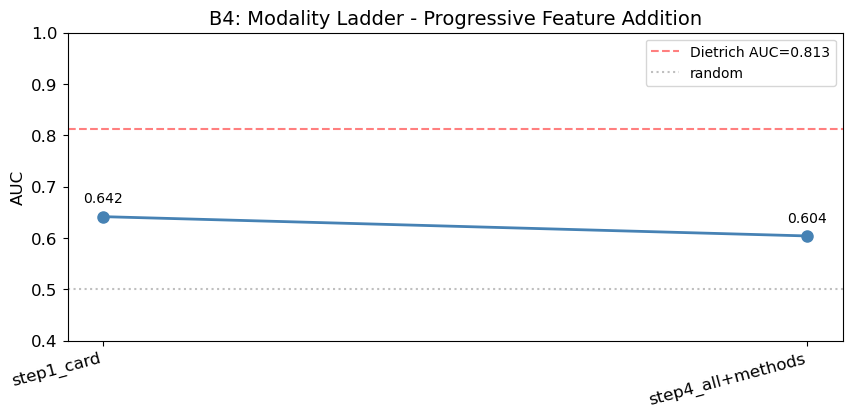

  Plot: cell_b4/modality_ladder_20260628_003657.png


In [7]:
# @title CELL B4: COMBINED UNSUPERVISED (progressive modality ladder)
# =============================================================================
# Progressive combination: what does adding each modality buy you?
# Rank-averaged combination of all available B0-B3 scores.
# =============================================================================
print("=" * 70)
print("CELL B4: COMBINED UNSUPERVISED (modality ladder)")
print("=" * 70)

from scipy.stats import rankdata

# --- collect all available unsupervised scores ---
all_scores = {}

# B0 single-feature scores
if b0_results:
    for label, r in b0_results.items():
        score_df = pd.DataFrame({
            'building_id': r['building_ids'],
            'city': r['cities'],
            f'score_{label}': r['scores'],
        })
        all_scores[label] = score_df

# B1 PWTT VV
if pwtt_scores is not None and 'B1_PWTT_VV' in EXPERIMENT_LOG:
    direction = EXPERIMENT_LOG['B1_PWTT_VV'].get('direction', '|t|')
    pwtt_vals = np.abs(pwtt_scores['pwtt_t'].values) if direction == '|t|' else -pwtt_scores['pwtt_t'].values
    all_scores['pwtt_vv'] = pd.DataFrame({
        'building_id': pwtt_scores['building_id'].values,
        'city': pwtt_scores['city'].values,
        'score_pwtt_vv': pwtt_vals,
    })

# B1 PWTT VH
if pwtt_scores_vh is not None and 'B1_PWTT_VH' in EXPERIMENT_LOG:
    direction = EXPERIMENT_LOG['B1_PWTT_VH'].get('direction', '|t|')
    pwtt_vh_vals = np.abs(pwtt_scores_vh['pwtt_t_vh'].values) if direction == '|t|' else -pwtt_scores_vh['pwtt_t_vh'].values
    all_scores['pwtt_vh'] = pd.DataFrame({
        'building_id': pwtt_scores_vh['building_id'].values,
        'city': pwtt_scores_vh['city'].values,
        'score_pwtt_vh': pwtt_vh_vals,
    })

# B2 CCD from product_prepost
coh_bl_mean_b4 = [c for c in df.columns if 'coh' in c.lower() and 'baseline' in c.lower() and 'mean' in c.lower()]
coh_as_mean_b4 = [c for c in df.columns if 'coh' in c.lower() and ('assessment' in c.lower() or 'post_baseline' in c.lower()) and 'mean' in c.lower()]
if coh_bl_mean_b4 and coh_as_mean_b4:
    bl_col = coh_bl_mean_b4[0]
    as_col = coh_as_mean_b4[0]
    ccd_sub = df[['building_id', 'city', bl_col, as_col]].dropna().copy()
    ccd_sub['score_ccd'] = ccd_sub[bl_col] - ccd_sub[as_col]
    all_scores['ccd'] = ccd_sub[['building_id', 'city', 'score_ccd']]

# B3 log-ratio VV
_bl = [c for c in df.columns if c.startswith('s1__vv__baseline__mean')]
_as = [c for c in df.columns if c.startswith('s1__vv__assessment__mean')]
if _bl and _as:
    lr_sub = df[['building_id', 'city', _bl[0], _as[0]]].dropna().copy()
    lr_sub['score_logratio'] = -(lr_sub[_as[0]] - lr_sub[_bl[0]])
    all_scores['logratio'] = lr_sub[['building_id', 'city', 'score_logratio']]

print(f"  Available score components: {sorted(all_scores.keys())}")

# --- define modality ladder ---
card_labels = [k for k in all_scores if k.startswith('s1_v')]
coh_labels = [k for k in all_scores if k.startswith('s1_coh')]
optical_labels = [k for k in all_scores if k.startswith('s2_') or k.startswith('idx_') or k.startswith('comp_')]
method_labels = [k for k in all_scores if k in ('pwtt_vv', 'pwtt_vh', 'ccd', 'logratio')]

ladder_steps = []
if card_labels:
    ladder_steps.append(('step1_card', card_labels))
if coh_labels:
    ladder_steps.append(('step2_card+coh', card_labels + coh_labels))
if optical_labels:
    ladder_steps.append(('step3_card+coh+optical', card_labels + coh_labels + optical_labels))
if method_labels:
    ladder_steps.append(('step4_all+methods', card_labels + coh_labels + optical_labels + method_labels))

all_labels = list(all_scores.keys())
if not ladder_steps or all_labels != ladder_steps[-1][1]:
    ladder_steps.append(('step_full', all_labels))

print(f"\n  Modality ladder:")
for step_name, step_labels in ladder_steps:
    print(f"    {step_name}: {len(step_labels)} scores")

# --- evaluate each ladder step ---
ref = df[['building_id', 'city', TARGET_COL]].drop_duplicates()
ref = ref[ref[TARGET_COL] >= 0]

print(f"\n  {'Step':<35s} {'N_scores':>9s} {'N_bldg':>8s} {'AUC':>7s}")
print(f"  {'-'*35} {'-'*9} {'-'*8} {'-'*7}")

ladder_results = {}

for step_name, step_labels in ladder_steps:
    merged = ref.copy()
    valid_labels = []
    for label in step_labels:
        if label not in all_scores:
            continue
        sdf = all_scores[label]
        score_col = [c for c in sdf.columns if c.startswith('score_')][0]
        merged = merged.merge(sdf[['building_id', 'city', score_col]], on=['building_id', 'city'], how='inner')
        valid_labels.append(score_col)

    merged = merged.dropna(subset=valid_labels)
    if len(merged) < 50 or merged[TARGET_COL].nunique() < 2:
        print(f"  {step_name:<35s} {len(valid_labels):>9d} {'SKIP':>8s}")
        continue

    y = merged[TARGET_COL].values

    for col in valid_labels:
        merged[f'{col}_rank'] = rankdata(merged[col]) / len(merged)

    rank_cols = [c for c in merged.columns if c.endswith('_rank')]
    merged['combined_score'] = merged[rank_cols].mean(axis=1)

    auc = roc_auc_score(y, merged['combined_score'].values)
    print(f"  {step_name:<35s} {len(valid_labels):>9d} {len(merged):>8d} {auc:>7.3f}")

    EXPERIMENT_LOG[f'B4_{step_name}'] = {
        'auc': auc, 'f1': np.nan,
        'n_features': len(valid_labels),
        'method': 'unsupervised_combined',
    }
    ladder_results[step_name] = {'auc': auc, 'n_scores': len(valid_labels), 'n_bldg': len(merged)}

    registry.log_experiment(
        cell_id='cell_b4', experiment_name=f'B4_{step_name}',
        parquet_name='bda_product_prepost',
        tier_selection=TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0,1,2],
        classifier_name='unsupervised_combined',
        feature_set_name=step_name, feature_cols=valid_labels,
        cv_method='unsupervised', n_folds=0, imputation='none',
        y_true=y, y_proba=merged['combined_score'].values,
        groups=merged['city'].values,
        note=f'Modality ladder: {step_name}, rank-averaged',
        tags=['unsupervised', 'combined', 'ladder', step_name],
    )

# --- OR-rule for the full combination ---
if ladder_steps:
    full_labels = ladder_steps[-1][1]
    merged_full = ref.copy()
    valid_full = []
    for label in full_labels:
        if label not in all_scores:
            continue
        sdf = all_scores[label]
        score_col = [c for c in sdf.columns if c.startswith('score_')][0]
        merged_full = merged_full.merge(sdf[['building_id', 'city', score_col]], on=['building_id', 'city'], how='inner')
        valid_full.append(score_col)

    merged_full = merged_full.dropna(subset=valid_full)
    if len(merged_full) > 50 and merged_full[TARGET_COL].nunique() >= 2:
        y_full = merged_full[TARGET_COL].values
        or_flags = np.zeros(len(merged_full), dtype=bool)
        for col in valid_full:
            threshold = np.percentile(merged_full[col], 90)
            or_flags |= (merged_full[col] >= threshold).values
        auc_or = roc_auc_score(y_full, or_flags.astype(float))
        f1_or = f1_score(y_full, or_flags.astype(int))
        print(f"\n  OR-rule (any > 90th pct): AUC={auc_or:.3f}  F1={f1_or:.3f}")

# ladder plot
if ladder_results:
    fig, ax = plt.subplots(figsize=(10, 4))
    steps = list(ladder_results.keys())
    aucs = [ladder_results[s]['auc'] for s in steps]
    ax.plot(steps, aucs, 'o-', color='steelblue', linewidth=2, markersize=8)
    for i, (s, a) in enumerate(zip(steps, aucs)):
        ax.annotate(f'{a:.3f}', (i, a), textcoords='offset points', xytext=(0, 10), ha='center')
    ax.set_ylabel('AUC')
    ax.set_title('B4: Modality Ladder - Progressive Feature Addition')
    ax.axhline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich AUC=0.813')
    ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5, label='random')
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    plt.xticks(rotation=15, ha='right')
    save_fig(fig, 'modality_ladder', 'cell_b4')


# CELL B5: UISEM BASELINE (Ahmad et al. 2024)

RF+GB+XGB soft voting, all multimodal features, GroupKFold.


In [8]:
# @title CELL B5: UISEM BASELINE (RF+GB+XGB soft voting, GroupKFold)
# =============================================================================
# Ahmad et al. 2024 adapted: soft-voting ensemble on all features.
# Parquet: bda_product_prepost (all_multimodal features).
# =============================================================================
print("=" * 70)
print("CELL B5: UISEM ENSEMBLE BASELINE")
print("=" * 70)

# with AdaBoost
clf_with_ab = build_uisem(include_adaboost=True)
X, y, groups, clean = prepare_Xy(all_feature_cols)
if X is not None:
    res = evaluate_groupkfold(clf_with_ab, X, y, groups, "B5_UISEM_all_features")
    log_result(res, cell_id='cell_b5', parquet_name='bda_product_prepost',
               feature_set_name='all_multimodal', classifier_name='UISEM_RF+GB+XGB+AB',
               feature_cols=clean, groups=groups,
               note='Ahmad 2024 UISEM: RF+GB+XGB+AdaBoost soft voting, all features',
               tags=['uisem', 'ensemble', 'ahmad2024'])

    # individual sub-classifiers for comparison
    print(f"\n  Individual sub-classifiers:")
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=RANDOM_STATE,
                                 n_jobs=-1, class_weight='balanced')
    res_rf = evaluate_groupkfold(rf, X, y, groups, "B5_sub_RF")
    log_result(res_rf, cell_id='cell_b5', parquet_name='bda_product_prepost',
               feature_set_name='all_multimodal', classifier_name='RF-200',
               feature_cols=clean, groups=groups, note='UISEM sub-classifier: RF',
               tags=['uisem', 'sub_classifier'])

    gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)
    res_gb = evaluate_groupkfold(gb, X, y, groups, "B5_sub_GBM")
    log_result(res_gb, cell_id='cell_b5', parquet_name='bda_product_prepost',
               feature_set_name='all_multimodal', classifier_name='GBM',
               feature_cols=clean, groups=groups, note='UISEM sub-classifier: GBM',
               tags=['uisem', 'sub_classifier'])

    if HAS_XGB:
        xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, scale_pos_weight=5,
                             eval_metric='logloss', verbosity=0)
        res_xgb = evaluate_groupkfold(xgb, X, y, groups, "B5_sub_XGB")
        log_result(res_xgb, cell_id='cell_b5', parquet_name='bda_product_prepost',
                   feature_set_name='all_multimodal', classifier_name='XGBoost',
                   feature_cols=clean, groups=groups, note='UISEM sub-classifier: XGBoost',
                   tags=['uisem', 'sub_classifier'])
else:
    print("  Insufficient features for UISEM")


CELL B5: UISEM ENSEMBLE BASELINE
    B5_UISEM_all_features                   : AUC=0.565 (+/-0.076)  F1=0.004
  REG: B5_UISEM_all_features                         AUC=0.5647 F1=0.0043 n=598595 feat=311 cities=21 [NB09b/cell_b5]

  Individual sub-classifiers:
    B5_sub_RF                               : AUC=0.443 (+/-0.034)  F1=0.001
  REG: B5_sub_RF                                     AUC=0.4433 F1=0.0014 n=598595 feat=311 cities=21 [NB09b/cell_b5]
    B5_sub_GBM                              : AUC=0.672 (+/-0.057)  F1=0.015
  REG: B5_sub_GBM                                    AUC=0.6717 F1=0.0151 n=598595 feat=311 cities=21 [NB09b/cell_b5]
    B5_sub_XGB                              : AUC=0.584 (+/-0.064)  F1=0.046
  REG: B5_sub_XGB                                    AUC=0.5842 F1=0.0461 n=598595 feat=311 cities=21 [NB09b/cell_b5]


# CELL B6: ADABOOST ABLATION


In [9]:
# @title CELL B6: ADABOOST ABLATION (Ahmad 2024 Section 4.2)
# Paper found AdaBoost had negligible impact for urban impervious surface.
# Test if same holds for BDA.
print("=" * 70)
print("CELL B6: ADABOOST ABLATION")
print("=" * 70)

X, y, groups, clean = prepare_Xy(all_feature_cols)
if X is not None:
    clf_no_ab = build_uisem(include_adaboost=False)
    res_no_ab = evaluate_groupkfold(clf_no_ab, X, y, groups, "B6_UISEM_no_AdaBoost")
    log_result(res_no_ab, cell_id='cell_b6', parquet_name='bda_product_prepost',
               feature_set_name='all_multimodal', classifier_name='UISEM_RF+GB+XGB',
               feature_cols=clean, groups=groups,
               note='UISEM without AdaBoost (Ahmad 2024 ablation)',
               tags=['uisem', 'adaboost_ablation'])

    ab_only = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
    res_ab = evaluate_groupkfold(ab_only, X, y, groups, "B6_AdaBoost_alone")
    log_result(res_ab, cell_id='cell_b6', parquet_name='bda_product_prepost',
               feature_set_name='all_multimodal', classifier_name='AdaBoost',
               feature_cols=clean, groups=groups,
               note='AdaBoost alone for ablation comparison',
               tags=['uisem', 'adaboost_ablation'])

    with_ab = EXPERIMENT_LOG.get('B5_UISEM_all_features', {}).get('auc', np.nan)
    without_ab = EXPERIMENT_LOG.get('B6_UISEM_no_AdaBoost', {}).get('auc', np.nan)
    if not np.isnan(with_ab) and not np.isnan(without_ab):
        delta = with_ab - without_ab
        print(f"\n  AdaBoost impact: {delta:+.3f} AUC ({with_ab:.3f} with vs {without_ab:.3f} without)")
        print(f"  {'Negligible' if abs(delta) < 0.005 else 'Positive' if delta > 0 else 'Negative'} impact")


CELL B6: ADABOOST ABLATION
    B6_UISEM_no_AdaBoost                    : AUC=0.530 (+/-0.070)  F1=0.005
  REG: B6_UISEM_no_AdaBoost                          AUC=0.5305 F1=0.0048 n=598595 feat=311 cities=21 [NB09b/cell_b6]
    B6_AdaBoost_alone                       : AUC=0.611 (+/-0.046)  F1=0.002
  REG: B6_AdaBoost_alone                             AUC=0.6107 F1=0.0024 n=598595 feat=311 cities=21 [NB09b/cell_b6]

  AdaBoost impact: +0.034 AUC (0.565 with vs 0.530 without)
  Positive impact


# CELL B7: UISEM SENSOR ABLATION


In [10]:
# @title CELL B7: UISEM SENSOR ABLATION
# =============================================================================
# UISEM ensemble across sensor groups: CARD-only, COH-only, MS-only, delta-only, combos.
# Parquet: bda_product_prepost (same as B5).
# =============================================================================
print("=" * 70)
print("CELL B7: UISEM SENSOR ABLATION")
print("=" * 70)

for gname, feats in sorted(ABLATION_GROUPS.items(), key=lambda x: len(x[1])):
    X, y, groups, clean = prepare_Xy(feats)
    if X is None:
        print(f"    {gname:25s}: SKIP (insufficient features)")
        continue
    clf = build_uisem(include_adaboost=False)
    res = evaluate_groupkfold(clf, X, y, groups, f"B7_UISEM_{gname}")
    log_result(res, cell_id='cell_b7', parquet_name='bda_product_prepost',
               feature_set_name=gname, classifier_name='UISEM_RF+GB+XGB',
               feature_cols=clean, groups=groups,
               note=f'UISEM sensor ablation: {gname}',
               tags=['uisem', 'sensor_ablation', gname])


CELL B7: UISEM SENSOR ABLATION
    B7_UISEM_coh_only                       : AUC=0.532 (+/-0.053)  F1=0.021
  REG: B7_UISEM_coh_only                             AUC=0.5321 F1=0.0209 n=102110 feat=18 cities=12 [NB09b/cell_b7]
    B7_UISEM_delta_only                     : AUC=0.412 (+/-0.070)  F1=0.003
  REG: B7_UISEM_delta_only                           AUC=0.4121 F1=0.0027 n=368288 feat=22 cities=21 [NB09b/cell_b7]
    B7_UISEM_card_only                      : AUC=0.502 (+/-0.115)  F1=0.004
  REG: B7_UISEM_card_only                            AUC=0.5016 F1=0.0041 n=368288 feat=96 cities=21 [NB09b/cell_b7]
    B7_UISEM_card+coh                       : AUC=0.543 (+/-0.050)  F1=0.016
  REG: B7_UISEM_card+coh                             AUC=0.5428 F1=0.0163 n=368288 feat=114 cities=21 [NB09b/cell_b7]
    B7_UISEM_card+coh+delta                 : AUC=0.497 (+/-0.094)  F1=0.017
  REG: B7_UISEM_card+coh+delta                       AUC=0.4973 F1=0.0167 n=368288 feat=136 cities=21 [NB09b/cell_b

# CELL B8: COMPARISON TABLE (all methods)


CELL B8: COMPARISON TABLE

  Method                                            AUC      F1            Type  N_feat
  --------------------------------------------- ------- ------- --------------- -------
  Dietrich 2025 (paper)                           0.813   0.749           paper      28
  Ballinger 2024 PWTT (paper)                     0.870      --           paper       1
  B0_single_s1_vh_max                             0.639      --    unsupervised       1
  B0_single_s1_vh_mean                            0.644      --    unsupervised       1
  B0_single_s1_vh_std                             0.554      --    unsupervised       1
  B0_single_s1_vv_max                             0.643      --    unsupervised       1
  B0_single_s1_vv_mean                            0.644      --    unsupervised       1
  B0_single_s1_vv_std                             0.575      --    unsupervised       1
  B1_PWTT_VH                                      0.625      --    unsupervised       1
  B1_

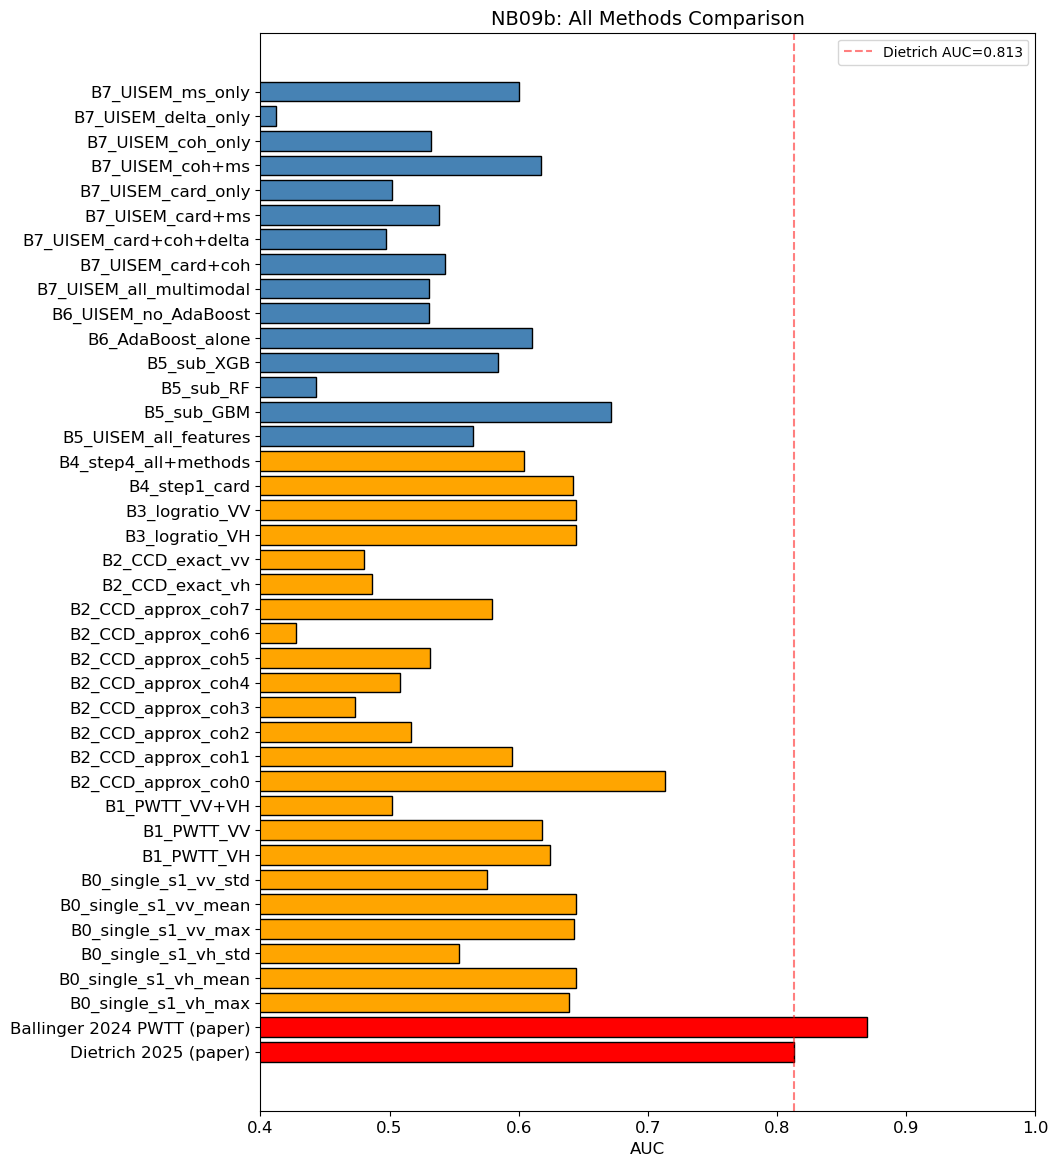

  Plot: cell_b8/comparison_bar_20260701_232553.png


PosixPath('/content/drive_f/masterthesis/results/nb09b/cell_b8/comparison_bar_20260701_232553.png')

In [11]:
# @title CELL B8: COMPARISON TABLE
# =============================================================================
# All NB09b methods + Dietrich paper reference + NB09a best (if available).
# =============================================================================
print("=" * 70)
print("CELL B8: COMPARISON TABLE")
print("=" * 70)

DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749}
BALLINGER_PAPER = {'auc': 0.87}

print(f"\n  {'Method':<45s} {'AUC':>7s} {'F1':>7s} {'Type':>15s} {'N_feat':>7s}")
print(f"  {'-'*45} {'-'*7} {'-'*7} {'-'*15} {'-'*7}")

# paper references
print(f"  {'Dietrich 2025 (paper)':<45s} {DIETRICH_PAPER['auc']:>7.3f} {DIETRICH_PAPER['f1']:>7.3f} {'paper':>15s} {'28':>7s}")
print(f"  {'Ballinger 2024 PWTT (paper)':<45s} {BALLINGER_PAPER['auc']:>7.3f} {'--':>7s} {'paper':>15s} {'1':>7s}")

# our results
for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    method = res.get('method', 'supervised')
    auc = res.get('auc', np.nan)
    f1 = res.get('f1', np.nan)
    nf = res.get('n_features', '?')
    auc_str = f"{auc:.3f}" if not np.isnan(auc) else "--"
    f1_str = f"{f1:.3f}" if not np.isnan(f1) else "--"
    print(f"  {key:<45s} {auc_str:>7s} {f1_str:>7s} {method:>15s} {str(nf):>7s}")

# highlight best unsupervised and best supervised
unsup = {k: v for k, v in EXPERIMENT_LOG.items() if v.get('method', '').startswith('unsup')}
sup = {k: v for k, v in EXPERIMENT_LOG.items() if not v.get('method', '').startswith('unsup')}

if unsup:
    best_unsup = max(unsup.items(), key=lambda x: x[1].get('auc', 0))
    print(f"\n  Best unsupervised: {best_unsup[0]} (AUC={best_unsup[1]['auc']:.3f})")
if sup:
    best_sup = max(sup.items(), key=lambda x: x[1].get('auc', 0))
    print(f"  Best supervised:   {best_sup[0]} (AUC={best_sup[1]['auc']:.3f})")



# save comparison table
comp_rows = []
comp_rows.append({'method': 'Dietrich 2025 (paper)', 'auc': 0.813, 'f1': 0.749, 'type': 'paper', 'n_features': 28})
comp_rows.append({'method': 'Ballinger 2024 PWTT (paper)', 'auc': 0.87, 'f1': np.nan, 'type': 'paper', 'n_features': 1})
for key in sorted(EXPERIMENT_LOG.keys()):
    res = EXPERIMENT_LOG[key]
    comp_rows.append({
        'method': key, 'auc': res.get('auc', np.nan), 'f1': res.get('f1', np.nan),
        'type': res.get('method', 'supervised'), 'n_features': res.get('n_features', 0),
    })
comp_df = pd.DataFrame(comp_rows)
save_result(comp_df, 'comparison_table', 'cell_b8')

# register paper references
registry.log_reference('Dietrich_2025', auc=0.813, f1=0.749,
                        precision=0.671, recall=0.846, n_features=28,
                        paper='Dietrich et al. 2025', note='GEE RF, geographic split')
registry.log_reference('Ballinger_2024_PWTT', auc=0.87, n_features=1,
                        paper='Ballinger 2024', note='unsupervised PWTT on Ukraine')

# bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, max(4, len(comp_df) * 0.35)))
colors = ['red' if t == 'paper' else 'orange' if 'unsup' in str(t) else 'steelblue' for t in comp_df['type']]
bars = ax.barh(comp_df['method'], comp_df['auc'].fillna(0), color=colors, edgecolor='black')
ax.set_xlabel('AUC')
ax.set_xlim(0.4, 1.0)
ax.set_title('NB09b: All Methods Comparison')
ax.axvline(0.813, color='red', linestyle='--', alpha=0.5, label='Dietrich AUC=0.813')
ax.legend()
save_fig(fig, 'comparison_bar', 'cell_b8')


In [12]:
# @title CELL 19: SAVE REGISTRY
registry.save()


  SAVED: NB09b_experiments_20260628_003554.json (40 experiments)
  SAVED: NB09b_experiments_20260628_003554.csv


PosixPath('/content/drive_f/masterthesis/results/registry')